# 02_data_validation — データ品質チェック

実施内容:
- 欠損率チェック
- 異常値検出（3σ法）
- 分布確認
- 重複チェック
- レポート自動生成 → `reports/data_validation_report.md`

In [1]:
import sys, json
from pathlib import Path
_NB_DIR = Path().resolve()
if _NB_DIR.name != 'notebooks': _NB_DIR = _NB_DIR.parent
if str(_NB_DIR) not in sys.path: sys.path.insert(0, str(_NB_DIR))
from utils.nb_config import *

_cfg_file = NB_DIR / 'config.json'
if _cfg_file.exists():
    _cfg = json.loads(_cfg_file.read_text(encoding='utf-8'))
    DATA_SOURCE_MODE = _cfg.get('DATA_SOURCE_MODE', DATA_SOURCE_MODE)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Meiryo', 'Yu Gothic', 'MS Gothic', 'DejaVu Sans']

from keiba_ai.db_ultimate_loader import (
    load_ultimate_training_frame,
    load_ultimate_training_frame_cached,
    _repo_root_from_db_path,
    _save_training_cache,
    _optimize_dataframe_memory,
    )
print(f"DATA_SOURCE_MODE = {DATA_SOURCE_MODE}")

DATA_SOURCE_MODE = existing


In [2]:
# ── データ読み込み + プロファイリング + キャッシュ ───────────────────
import time
import psutil
import os

_db = get_db_path(DATA_SOURCE_MODE)
print(f"DB: {_db}")

_cache_dir = _repo_root_from_db_path(_db) / 'cache'
print(f"cache_dir: {_cache_dir}")

_proc = psutil.Process(os.getpid())
_mem_before_gb = _proc.memory_info().rss / 1024**3
_start = time.perf_counter()
print(f"memory_before: {_mem_before_gb:.3f} GB")

df_raw = load_ultimate_training_frame_cached(
    _db,
    cache_dir=_cache_dir,
    prefer_parquet=True,
    profile=True,
    optimize_memory=True,
    )

_elapsed = time.perf_counter() - _start
_mem_after_gb = _proc.memory_info().rss / 1024**3
print(f"memory_after: {_mem_after_gb:.3f} GB")
print(f"elapsed: {_elapsed:.3f} sec")

print(f"行数: {len(df_raw):,}  列数: {df_raw.shape[1]}")
print("\n=== DataFrame Profile ===")
print(df_raw.shape)
print(df_raw.memory_usage(deep=True).sum() / 1024**2)
print(df_raw.dtypes.value_counts())
print(f"object列数: {(df_raw.dtypes == 'object').sum()}")
print(f"category列数: {(df_raw.dtypes.astype(str) == 'category').sum()}")

if hasattr(df_raw, 'attrs') and df_raw.attrs.get('stage_profile'):
    print("\n=== Stage Profile(sec) ===")
    for _k, _v in df_raw.attrs['stage_profile'].items():
        print(f"{_k:16s}: {_v}")

df_raw.head(3)

DB: C:\Users\yuki2\Documents\ws\keiba-ai-pro\keiba\data\keiba_ultimate.db
cache_dir: C:\Users\yuki2\Documents\ws\keiba-ai-pro\cache
memory_before: 0.130 GB
→ cache hit: C:\Users\yuki2\Documents\ws\keiba-ai-pro\cache\ultimate_frame.pkl
memory_after: 0.397 GB
elapsed: 0.178 sec
行数: 575,346  列数: 132

=== DataFrame Profile ===
(575346, 132)


327.7384252548218
float32     64
int8         6
category     5
object       3
category     3
category     2
category     2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
float64      1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
int16        1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64
object列数: 3
category列数: 57


,race_id,finish_position,bracket_number,horse_number,horse_name,horse_url,horse_id,sex_age,sex,age,...,prev5_race_class,finish,time,last_3f_time,horse_weight,horse_weight_change,burden_weight,time_seconds,surface_ja,surface_en
0,202445010106,2.0,4,4,プラウドウィッチ,https://db.netkeiba.com/horse/2020103445/,2020103445,牝4,牝,4,...,NaN,2.0,0:56.2,38.900002,444.0,-4.0,54.0,56.200001,ダート,dirt
1,202445010106,3.0,7,9,マイネルリベラル,https://db.netkeiba.com/horse/2017110105/,2017110105,セ7,セ,7,...,NaN,3.0,0:56.5,39.099998,489.0,4.0,56.0,56.500000,ダート,dirt
2,202445010105,5.0,6,6,ミナトイチバン,https://db.netkeiba.com/horse/2016109150/,2016109150,牡8,牡,8,...,NaN,5.0,1:36.7,41.700001,458.0,-1.0,56.0,96.699997,ダート,dirt


In [3]:
# ── 1. 欠損率チェック ─────────────────────────────────────────
_null_rate = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
_null_df = pd.DataFrame({'欠損率(%)': _null_rate, '欠損件数': df_raw.isnull().sum()})
_null_df = _null_df[_null_df['欠損率(%)'] > 0]

print(f"欠損あり列数: {len(_null_df)} / {df_raw.shape[1]}")
print("\n欠損率上位20列:")
display(_null_df.head(20))

# 閾値別集計
for thr in (10, 50, 90):
    n = (_null_rate > thr).sum()
    print(f"欠損率 > {thr}%: {n} 列")

欠損あり列数: 98 / 132

欠損率上位20列:


,欠損率(%),欠損件数
_shutuba,99.492132,572424
corner_1,11.072989,63708
corner_2,11.619269,66851
corner_3,44.040977,253388
corner_4,48.683053,280096
corner_positions,0.507868,2922
corner_positions_list,98.946547,569285
dam,3.959009,22778
damsire,3.960747,22788
date,99.492132,572424


欠損率 > 10%: 77 列
欠損率 > 50%: 30 列
欠損率 > 90%: 11 列


In [4]:
# ── 2. 異常値検出（数値列・3σ法）────────────────────────────
_num_cols = df_raw.select_dtypes(include='number').columns.tolist()
_anomaly_rows = []
for c in _num_cols:
    s = df_raw[c].dropna()
    if len(s) < 30: continue
    mu, sd = s.mean(), s.std()
    if sd == 0: continue
    n_out = ((s < mu - 3*sd) | (s > mu + 3*sd)).sum()
    pct = n_out / len(s) * 100
    if pct > 0.1:
        _anomaly_rows.append({'column': c, 'mean': round(mu,3), 'std': round(sd,3),
                               '外れ値件数': n_out, '外れ値率(%)': round(pct,2)})
_anomaly_df = pd.DataFrame(_anomaly_rows).sort_values('外れ値率(%)', ascending=False)
print(f"外れ値 > 0.1% の列数: {len(_anomaly_df)}")
display(_anomaly_df.head(20))

外れ値 > 0.1% の列数: 56


,column,mean,std,外れ値件数,外れ値率(%)
1,jockey_weight,1.133530e+02,1.719200e+02,28741,5.00
54,burden_weight,1.133530e+02,1.719200e+02,28741,5.00
52,horse_weight,5.217930e+02,1.645220e+02,23971,4.20
6,weight_kg,5.217930e+02,1.645220e+02,23971,4.20
5,weight,5.261180e+02,1.720730e+02,203,3.37
9,horse_total_prize_money,8.846547e+06,1.742368e+07,1835,3.19
2,odds,5.260700e+01,8.172900e+01,14206,2.51
55,time_seconds,1.010550e+02,2.602600e+01,11863,2.10
11,horse_total_wins,3.114000e+00,3.606000e+00,1200,2.06
29,prev3_race_distance,1.532555e+03,3.510730e+02,8156,2.04


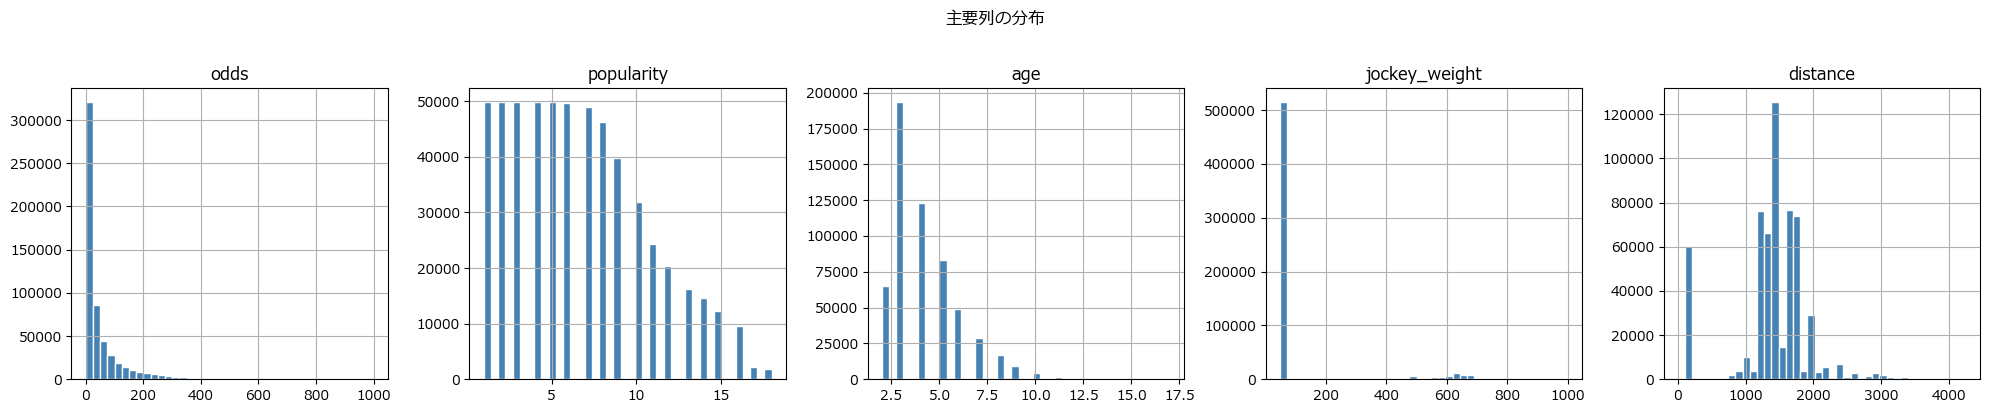

In [5]:
# ── 3. 分布確認（主要数値列）────────────────────────────────
_KEY_COLS = ['odds', 'popularity', 'age', 'jockey_weight', 'distance']
_plot_cols = [c for c in _KEY_COLS if c in df_raw.columns]

fig, axes = plt.subplots(1, len(_plot_cols), figsize=(4*len(_plot_cols), 4))
if len(_plot_cols) == 1: axes = [axes]
for ax, c in zip(axes, _plot_cols):
    df_raw[c].dropna().hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(c)
    ax.set_xlabel('')
plt.suptitle('主要列の分布', y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [6]:
# ── 4. 重複チェック ───────────────────────────────────────────
_dup_race = df_raw.duplicated(subset=['race_id', 'horse_id']).sum() if 'horse_id' in df_raw.columns else 0

# list型など unhashable な値を持つ列を除外してから完全重複チェック
_hashable_cols = [
    c for c in df_raw.columns
    if not df_raw[c].dropna().apply(lambda x: isinstance(x, (list, dict, set))).any()
]
_dup_full = df_raw[_hashable_cols].duplicated().sum()
_skipped = df_raw.shape[1] - len(_hashable_cols)

print(f"完全重複行数:               {_dup_full}  (unhashable列 {_skipped} 列を除外)")
print(f"(race_id, horse_id) 重複数: {_dup_race}")

# race_id 内の出走頭数分布
if 'race_id' in df_raw.columns:
    _n_per_race = df_raw.groupby('race_id').size()
    print(f"\n1レースあたり平均馬数: {_n_per_race.mean():.1f}")
    print(f"最小: {_n_per_race.min()}  最大: {_n_per_race.max()}")
    _invalid = (_n_per_race < 3).sum()
    print(f"3頭未満のレース数（異常）: {_invalid}")


完全重複行数:               0  (unhashable列 3 列を除外)
(race_id, horse_id) 重複数: 0

1レースあたり平均馬数: 11.5
最小: 0  最大: 18
3頭未満のレース数（異常）: 20


C:\Users\yuki2\AppData\Local\Temp\ipykernel_54024\500007951.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _n_per_race = df_raw.groupby('race_id').size()


In [7]:
# ── 5. データリーク候補列の確認 ───────────────────────────────
# FUTURE_FIELDS との照合（keiba_ai.constants と同一判定基準）
from keiba_ai.constants import FUTURE_FIELDS, UNNECESSARY_COLUMNS

_leak_present = [c for c in FUTURE_FIELDS if c in df_raw.columns]
_unnec_present = [c for c in UNNECESSARY_COLUMNS if c in df_raw.columns]
print(f"FUTURE_FIELDS 混入: {len(_leak_present)} 列  {_leak_present}")
print(f"UNNECESSARY_COLUMNS 混入: {len(_unnec_present)} 列")
if _leak_present:
    print("⚠ データリーク候補が存在します。03_feature_engineering で除外されます。")

FUTURE_FIELDS 混入: 16 列  ['corner_positions', 'last_3f_rank', 'last_3f_time', 'finish', 'finish_position', 'margin', 'corner_1', 'time_seconds', 'time_index', 'prize_money', 'corner_2', 'finish_time', 'corner_4', 'corner_positions_list', 'last_3f', 'corner_3']
UNNECESSARY_COLUMNS 混入: 70 列
⚠ データリーク候補が存在します。03_feature_engineering で除外されます。


In [8]:
# ── 6. レポート生成 ───────────────────────────────────────────
from datetime import datetime

_lines = [
    "# データ品質チェックレポート",
    f"",
    f"生成日時: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    f"DB: {_db}",
    f"行数: {len(df_raw):,}  列数: {df_raw.shape[1]}",
    "",
    "## 欠損率",
    f"- 欠損あり列数: {len(_null_df)} / {df_raw.shape[1]}",
]
for thr in (10, 50, 90):
    n = (_null_rate > thr).sum()
    _lines.append(f"- 欠損率 > {thr}%: {n} 列")

_lines += ["", "## 異常値（3σ法）",
           f"- 外れ値 > 0.1% の列数: {len(_anomaly_df)}"]
_lines += ["", "## 重複",
           f"- 完全重複: {_dup_full}  (race_id, horse_id): {_dup_race}"]
_lines += ["", "## データリーク候補",
           f"- FUTURE_FIELDS 混入: {len(_leak_present)} 列"]

_rpt = REPORTS_DIR / 'data_validation_report.md'
_rpt.write_text('\n'.join(_lines), encoding='utf-8')
print(f"レポート保存: {_rpt}")

レポート保存: C:\Users\yuki2\Documents\ws\keiba-ai-pro\notebooks\reports\data_validation_report.md


---
## Section 7 — 特徴量グループ別インスペクション

`feature_inspection.ipynb` Section 1 より移行。
`add_derived_features` 生成後の全列をグループ別・個別に確認する。

| セル | 内容 |
|---|---|
| FI-1 | 特徴量グループ別ドロップダウンインスペクション |
| FI-2 | 個別列インスペクション（ヒストグラム + 統計）|
| FI-3 | NaN率ランキング可視化 |
| FI-4 | `LightGBMFeatureOptimizer` 前処理前後比較 |
| FI-5 | 前処理後 NaN率比較チャート |


In [9]:
## ── FI-1: 特徴量グループ別インスペクション ───────────────────────────────
# feature_inspection.ipynb Cell 4 より移行
# df_raw は上セルで load_ultimate_training_frame 済みを再利用
# 未実行の場合は再ロードする

import ipywidgets as widgets
import matplotlib
matplotlib.rcParams['font.family'] = ['Meiryo', 'Yu Gothic', 'MS Gothic', 'DejaVu Sans']

# df_raw が未定義なら再ロード（cache優先）
if 'df_raw' not in dir():
    from keiba_ai.db_ultimate_loader import load_ultimate_training_frame_cached, _repo_root_from_db_path
    _db = get_db_path(DATA_SOURCE_MODE)
    _cache_dir = _repo_root_from_db_path(_db) / 'cache'
    df_raw = load_ultimate_training_frame_cached(_db, cache_dir=_cache_dir, prefer_parquet=True, optimize_memory=True)

# add_derived_features 実行（Section 1 セルと独立して動くよう）
if 'df_fi' not in dir():
    from keiba_ai.feature_engineering import add_derived_features
    print("特徴量生成中...")
    df_fi = add_derived_features(df_raw)
    print(f"完成フレーム: {df_fi.shape[0]:,}行 × {df_fi.shape[1]}列")

FEATURE_GROUPS_FI = {
    "01_レース基本情報": ["race_class_num","venue_code","race_num","n_horses","cos_date","sin_date",
                          "season","sex_code","frame_race_type","class_rank_adj","weight_vs_standard"],
    "02_コース特性":     ["straight_length","track_type","corner_radius","inner_bias","inner_advantage"],
    "03_馬属性・休養":   ["is_young","is_prime","is_veteran","running_style_num",
                          "rest_short","rest_normal","rest_long","rest_very_long"],
    "04_オッズ市場":     ["implied_prob","log_odds","odds_is_missing","implied_prob_norm",
                          "odds_rank_in_race","odds_z_in_race","market_entropy","top3_probability","popularity_normalized"],
    "05_前走・近走":     ["days_since_last_race","distance_change","prev_speed_index","prev_speed_zscore",
                          "speed_index_change","recent_form_weighted","form_trend","recent_form_5race",
                          "win_count_5","top3_count_5","prev_race_class_num","class_change"],
    "06_相手関係":       ["race_avg_prev_speed","race_max_prev_speed","speed_vs_race_avg","horse_speed_rank_pct"],
    "07_持ちタイム":     ["has_just_data","holding_just_speed","holding_just_time_rank"],
    "08_ラップ展開":     ["lap_200m","lap_400m","lap_600m","race_pace_front","race_pace_back","race_pace_diff"],
    "09_脚質":           ["corner_first","corner_last","corner_gain","running_style_code"],
    "10_速度指数":       ["sf_index_last","sf_index_2ago","sf_max_index","sf_course_max_index","sf_index_trend"],
    "11_調教":           ["last_training_time_3f","has_training_data","last_training_grade_encoded"],
    "12_通算統計":       ["horse_win_rate_exp","horse_show_rate_exp","jockey_win_rate","jockey_show_rate",
                          "trainer_win_rate","trainer_show_rate","sire_win_rate","gate_bracket_win_rate"],
    "13_欠損フラグ":     [c for c in df_fi.columns if c.endswith("_is_missing")],
}

def _inspect_group(group_name):
    cols = [c for c in FEATURE_GROUPS_FI.get(group_name, []) if c in df_fi.columns]
    missing = [c for c in FEATURE_GROUPS_FI.get(group_name, []) if c not in df_fi.columns]
    if missing: print(f"⚠ 未生成列 ({len(missing)}): {missing[:5]}...")
    if not cols: print("表示できる列がありません"); return
    rows = []
    for col in cols:
        s = df_fi[col]
        nan_pct = s.isna().mean() * 100
        rows.append({
            "column": col, "dtype": str(s.dtype), "nan_%": round(nan_pct, 1),
            "zero_%": round((s == 0).mean() * 100, 1) if pd.api.types.is_numeric_dtype(s) else "",
            "unique": s.nunique(dropna=True),
            "mean": round(s.mean(), 4) if pd.api.types.is_numeric_dtype(s) else "",
            "std":  round(s.std(),  4) if pd.api.types.is_numeric_dtype(s) else "",
        })
    grp_df = pd.DataFrame(rows)
    display(grp_df.style.background_gradient(subset=["nan_%"], cmap="Oranges").set_caption(group_name))

_dd_fi = widgets.Dropdown(
    options=list(FEATURE_GROUPS_FI.keys()), description="グループ:",
    layout=widgets.Layout(width="60%"),
)
_out_fi = widgets.Output()

def _on_grp_change(change):
    if change["type"] == "change" and change["name"] == "value":
        with _out_fi:
            _out_fi.clear_output()
            _inspect_group(change["new"])

_dd_fi.observe(_on_grp_change)
display(_dd_fi, _out_fi)
with _out_fi:
    _inspect_group(_dd_fi.value)


特徴量生成中...


C:\Users\yuki2\Documents\ws\keiba-ai-pro\keiba\keiba_ai\feature_engineering.py:491: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['n_horses'] = df.groupby('race_id', sort=False)['race_id'].transform('count')


C:\Users\yuki2\Documents\ws\keiba-ai-pro\keiba\keiba_ai\feature_engineering.py:664: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['implied_prob_norm'] = df.groupby('race_id')['implied_prob'].transform(


C:\Users\yuki2\Documents\ws\keiba-ai-pro\keiba\keiba_ai\feature_engineering.py:667: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['odds_rank_in_race'] = df.groupby('race_id')['odds'].rank(method='min', na_option='bottom')
C:\Users\yuki2\Documents\ws\keiba-ai-pro\keiba\keiba_ai\feature_engineering.py:668: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['odds_z_in_race']    = df.groupby('race_id')['odds'].transform(


C:\Users\yuki2\Documents\ws\keiba-ai-pro\keiba\keiba_ai\feature_engineering.py:674: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _prob_sum = _prob_raw_s.groupby(df['race_id'], sort=False).transform('sum')
C:\Users\yuki2\Documents\ws\keiba-ai-pro\keiba\keiba_ai\feature_engineering.py:678: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _entropy_by_race = _entropy_term.groupby(df['race_id'], sort=False).transform('sum')
C:\Users\yuki2\Documents\ws\keiba-ai-pro\keiba\keiba_ai\feature_engineering.py:680: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of p

...

C:\Users\yuki2\Documents\ws\keiba-ai-pro\keiba\keiba_ai\feature_engineering.py:1358: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['race_pace_diff'] = df['race_pace_front'] - df['race_pace_back']
C:\Users\yuki2\Documents\ws\keiba-ai-pro\keiba\keiba_ai\feature_engineering.py:1359: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['race_pace_ratio'] = np.where(
C:\Users\yuki2\Documents\ws\keiba-ai-pro\keiba\keiba_ai\feature_engineering.py:1372: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of ca

C:\Users\yuki2\Documents\ws\keiba-ai-pro\keiba\keiba_ai\feature_engineering.py:1381: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['sanrentan_z_in_races'] = df.groupby('race_id')['sanrentan_payout_log'].transform(
C:\Users\yuki2\Documents\ws\keiba-ai-pro\keiba\keiba_ai\feature_engineering.py:1065: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['corner_first'] = np.where(_c1.notna(), _c1, _c2)
C:\Users\yuki2\Documents\ws\keiba-ai-pro\keiba\keiba_ai\feature_engineering.py:1072: PerformanceWarning: DataFrame is highly fragment

完成フレーム: 575,346行 × 309列


Dropdown(description='グループ:', layout=Layout(width='60%'), options=('01_レース基本情報', '02_コース特性', '03_馬属性・休養', '04_…

Output()

In [10]:
## ── FI-2: 個別列インスペクション ─────────────────────────────────────────
# feature_inspection.ipynb Cell 5 より移行

_all_cols_fi = sorted(df_fi.columns.tolist())
_col_sel_fi = widgets.Combobox(
    placeholder="列名を入力または選択", options=_all_cols_fi,
    description="列:", layout=widgets.Layout(width="60%"), ensure_option=False,
)
_out2_fi = widgets.Output()

def _show_column_fi(col_name):
    _out2_fi.clear_output()
    with _out2_fi:
        if col_name not in df_fi.columns:
            print(f"'{col_name}' は存在しません"); return
        s = df_fi[col_name]
        nan_n = s.isna().sum()
        print(f"{'='*55}")
        print(f"列名  : {col_name}")
        print(f"dtype : {s.dtype}")
        print(f"行数  : {len(s):,}  有効: {s.notna().sum():,}  NaN: {nan_n:,} ({nan_n/len(s)*100:.1f}%)")
        print(f"unique: {s.nunique(dropna=True):,}")
        if pd.api.types.is_numeric_dtype(s):
            print(s.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_string())
            fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
            axes[0].hist(s.dropna(), bins=50, color="#4C78A8", edgecolor="white", linewidth=0.3)
            axes[0].set_title(f"{col_name}  (histogram)")
            vc = s.value_counts(dropna=True).head(20)
            axes[1].barh(vc.index.astype(str)[::-1], vc.values[::-1], color="#72B7B2")
            axes[1].set_title("top-20 values")
            plt.tight_layout(); plt.show()
        else:
            vc = s.value_counts(dropna=False).head(20)
            print("\nvalue_counts (top 20):"); print(vc.to_string())

def _on_col_change_fi(change):
    if change["type"] == "change" and change["name"] == "value":
        _show_column_fi(change["new"])

_col_sel_fi.observe(_on_col_change_fi)
display(_col_sel_fi, _out2_fi)
with _out2_fi:
    _show_column_fi("race_class_num")


Combobox(value='', description='列:', layout=Layout(width='60%'), options=('_shutuba', 'age', 'bracket_number',…

Output()

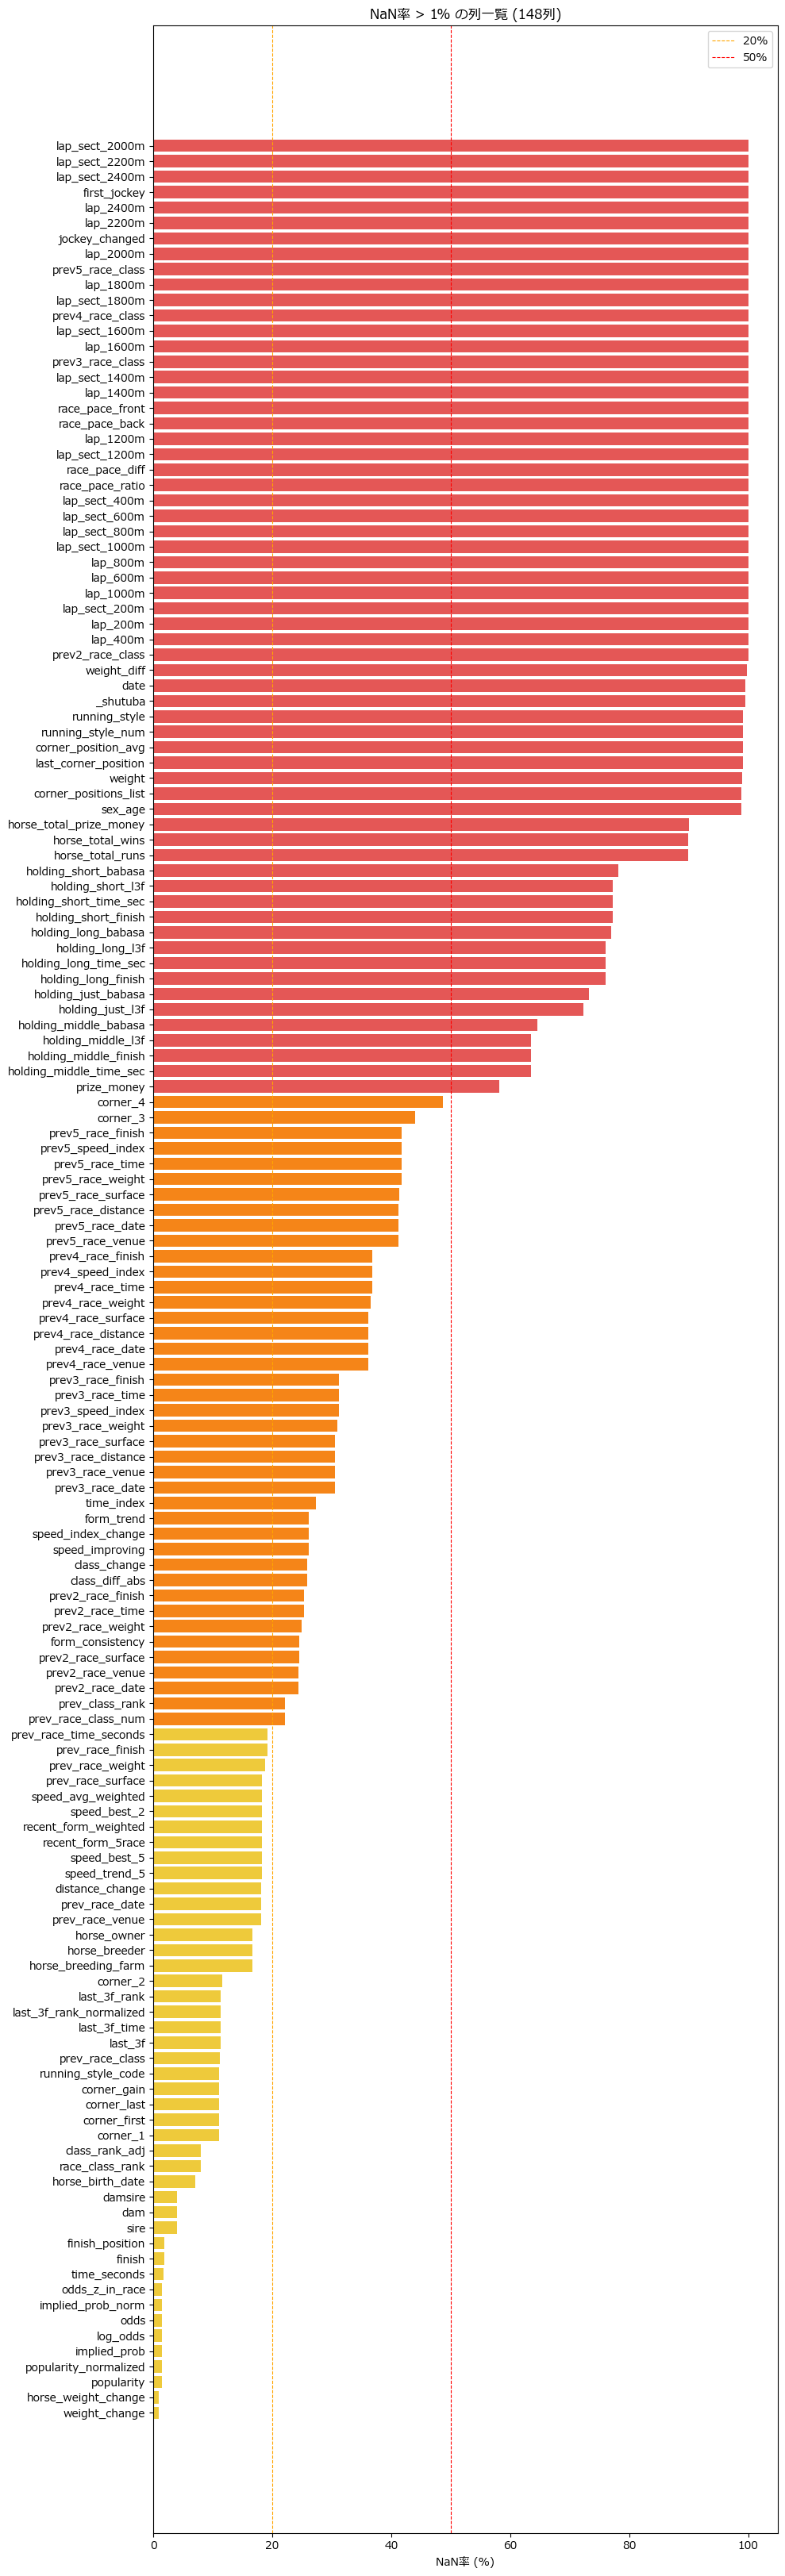

NaN = 0%   : 150列
NaN 1-20%  : 45列
NaN 20-50% : 41列
NaN > 50%  : 62列


In [11]:
## ── FI-3: NaN率ランキング可視化 ───────────────────────────────────────────
# feature_inspection.ipynb Cell 6 より移行

_nan_rates_fi = df_fi.isna().mean().sort_values(ascending=False)
_nan_top_fi   = _nan_rates_fi[_nan_rates_fi > 0.01].reset_index()
_nan_top_fi.columns = ["column", "nan_rate"]
_nan_top_fi["nan_%"] = (_nan_top_fi["nan_rate"] * 100).round(1)

fig_fi3, ax_fi3 = plt.subplots(figsize=(10, max(4, len(_nan_top_fi) * 0.22)))
_colors_fi3 = ["#E45756" if r > 0.5 else "#F58518" if r > 0.2 else "#EECA3B"
               for r in _nan_top_fi["nan_rate"]]
ax_fi3.barh(_nan_top_fi["column"][::-1], _nan_top_fi["nan_%"][::-1], color=_colors_fi3[::-1])
ax_fi3.axvline(20, color="orange", linestyle="--", linewidth=0.8, label="20%")
ax_fi3.axvline(50, color="red",    linestyle="--", linewidth=0.8, label="50%")
ax_fi3.set_xlabel("NaN率 (%)")
ax_fi3.set_title(f"NaN率 > 1% の列一覧 ({len(_nan_top_fi)}列)")
ax_fi3.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'nan_rate_ranking.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"NaN = 0%   : {(_nan_rates_fi == 0).sum()}列")
print(f"NaN 1-20%  : {((_nan_rates_fi > 0.01) & (_nan_rates_fi <= 0.2)).sum()}列")
print(f"NaN 20-50% : {((_nan_rates_fi > 0.2)  & (_nan_rates_fi <= 0.5)).sum()}列")
print(f"NaN > 50%  : {(_nan_rates_fi > 0.5).sum()}列")


In [12]:
## ── FI-4: 前処理前後の列比較 ──────────────────────────────────────────────
# feature_inspection.ipynb Cell 7/8 より移行
# LightGBMFeatureOptimizer を適用して前処理前後で削除・追加された列を確認する

from keiba_ai.lightgbm_feature_optimizer import LightGBMFeatureOptimizer
from keiba_ai.constants import UNNECESSARY_COLUMNS, FUTURE_FIELDS

_fi_target = "finish"   # 前処理用ターゲット（実際の学習ターゲットは 05 で設定）
_fi_opt = LightGBMFeatureOptimizer()
_df_fi_pre, _fi_cat = _fi_opt.fit_transform(df_fi.copy(), target_col=_fi_target)

_cols_before_fi = set(df_fi.columns)
_cols_after_fi  = set(_df_fi_pre.columns)
_dropped_fi = sorted(_cols_before_fi - _cols_after_fi)
_kept_fi    = sorted(_cols_before_fi & _cols_after_fi)

_compare_rows_fi = []
for c in _dropped_fi:
    nan_pct = df_fi[c].isna().mean() * 100
    reason = ("UNNECESSARY_COLUMNS" if c in UNNECESSARY_COLUMNS
              else "FUTURE_FIELDS" if c in FUTURE_FIELDS
              else "object型除外" if df_fi[c].dtype == object
              else "optimizer除外")
    _compare_rows_fi.append({"column": c, "dtype": str(df_fi[c].dtype),
                              "nan_%": round(nan_pct, 1), "reason": reason})
_compare_df_fi = pd.DataFrame(_compare_rows_fi)

print(f"前処理前: {df_fi.shape[1]} 列  →  前処理後: {_df_fi_pre.shape[1]} 列")
print(f"削除列: {len(_dropped_fi)}  カテゴリカル: {len(_fi_cat)}")
display(_compare_df_fi.style
        .applymap(lambda v: "background-color:#3a1a1a" if v == "FUTURE_FIELDS"
                  else ("background-color:#1a2a3a" if v == "UNNECESSARY_COLUMNS" else ""),
                  subset=["reason"])
        .background_gradient(subset=["nan_%"], cmap="Reds")
        .set_caption(f"削除列一覧 ({len(_dropped_fi)}列)"))


  ⚠ [L3-1] 未来情報列を除外 (25列): ['corner_gain', 'corner_positions', 'last_3f_rank', 'last_3f_time', 'last_corner_position', 'finish', 'last_3f_rank_normalized', 'finish_position', 'margin', 'corner_1', 'corner_position_avg', 'time_seconds', 'time_index', 'corner_last', 'prize_money', 'position_change', 'corner_2', 'finish_time', 'corner_first', 'corner_4', 'corner_positions_list', 'corner_position_variance', 'running_style_code', 'last_3f', 'corner_3']



【LightGBM特徴量最適化】学習モード

【1. 低カーディナリティ カテゴリカル変数】
処理: Label Encoding → LightGBMのcategorical_feature指定
  ✓ venue                          → venue_encoded                  (25種類)
  ✓ venue_code                     → venue_code_encoded             (31種類)


  ✓ track_type                     → track_type_encoded             (4種類)
  ✓ surface                        → surface_encoded                (4種類)
  ✓ weather                        → weather_encoded                (7種類)


  ✓ field_condition                → field_condition_encoded        (6種類)
  ✓ race_class                     → race_class_encoded             (32種類)
  ✓ course_direction               → course_direction_encoded       (4種類)


  ✓ sex                            → sex_encoded                    (3種類)
  ✓ corner_radius                  → corner_radius_encoded          (4種類)

  元のカテゴリカルカラムを削除: ['venue', 'venue_code', 'track_type', 'surface', 'weather', 'field_condition', 'race_class', 'course_direction', 'sex', 'corner_radius']

【2. 高カーディナリティ文字列列】
処理: 削除（統計特徴量は feature_engineering.py で計算済み）
  ✓ jockey_name → 削除


...

  ✓ holding_just_speed_is_missing → 削除
  ✓ holding_just_time_sec_is_missing → 削除
  ✓ last_training_time_3f_is_missing → 削除


  ✓ 性別ダミー（重複）削除: ['sex_code']

  ⚠️  欠損率90%超の列を除去 (39列): ['prev2_race_class', 'prev3_race_class', 'prev4_race_class', 'prev5_race_class', 'running_style_num', 'jockey_changed', 'first_jockey', 'lap_200m']...


  ⚠️  [fix-D] ゼロ分散列を除去 (22列): ['sf_index_2ago', 'sf_index_3ago', 'sf_max_index', 'sf_course_max_index', 'sf_dist_max_index', 'sf_index_trend', 'last_training_time_3f', 'last_training_grade_encoded', 'has_training_data', 'training_comment_score', 'horse_speed_rank_pct_is_missing', 'class_drop_is_missing', 'kai_num_is_missing', 'day_num_is_missing', 'last_training_grade_encoded_is_missing', 'training_comment_score_is_missing', 'sf_index_2ago_is_missing', 'sf_index_3ago_is_missing', 'sf_max_index_is_missing', 'sf_course_max_index_is_missing', 'sf_dist_max_index_is_missing', 'sf_index_trend_is_missing']

【最適化完了】
  元のカラム数: 111個
  カテゴリカル特徴量: 10個
    → LightGBMのcategorical_feature引数に指定: ['venue_encoded', 'venue_code_encoded', 'track_type_encoded', 'surface_encoded', 'weather_encoded']...

  推奨LightGBMパラメータ:
    'categorical_feature': ['venue_encoded', 'venue_code_encoded', 'track_type_encoded', 'surface_encoded', 'weather_encoded', 'field_condition_encoded', 'race_class_encoded', 'course_dire

C:\Users\yuki2\AppData\Local\Temp\ipykernel_54024\688879945.py:31: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: "background-color:#3a1a1a" if v == "FUTURE_FIELDS"


,column,dtype,nan_%,reason
0,_shutuba,category,99.500000,UNNECESSARY_COLUMNS
1,age,int8,0.000000,UNNECESSARY_COLUMNS
2,bracket_number,int8,0.000000,UNNECESSARY_COLUMNS
3,burden_weight,float32,0.000000,UNNECESSARY_COLUMNS
4,class_drop_is_missing,int64,0.000000,optimizer除外
5,corner_1,float32,11.100000,UNNECESSARY_COLUMNS
6,corner_2,float32,11.600000,UNNECESSARY_COLUMNS
7,corner_3,float32,44.000000,UNNECESSARY_COLUMNS
8,corner_4,float32,48.700000,UNNECESSARY_COLUMNS
9,corner_first,float32,11.100000,FUTURE_FIELDS


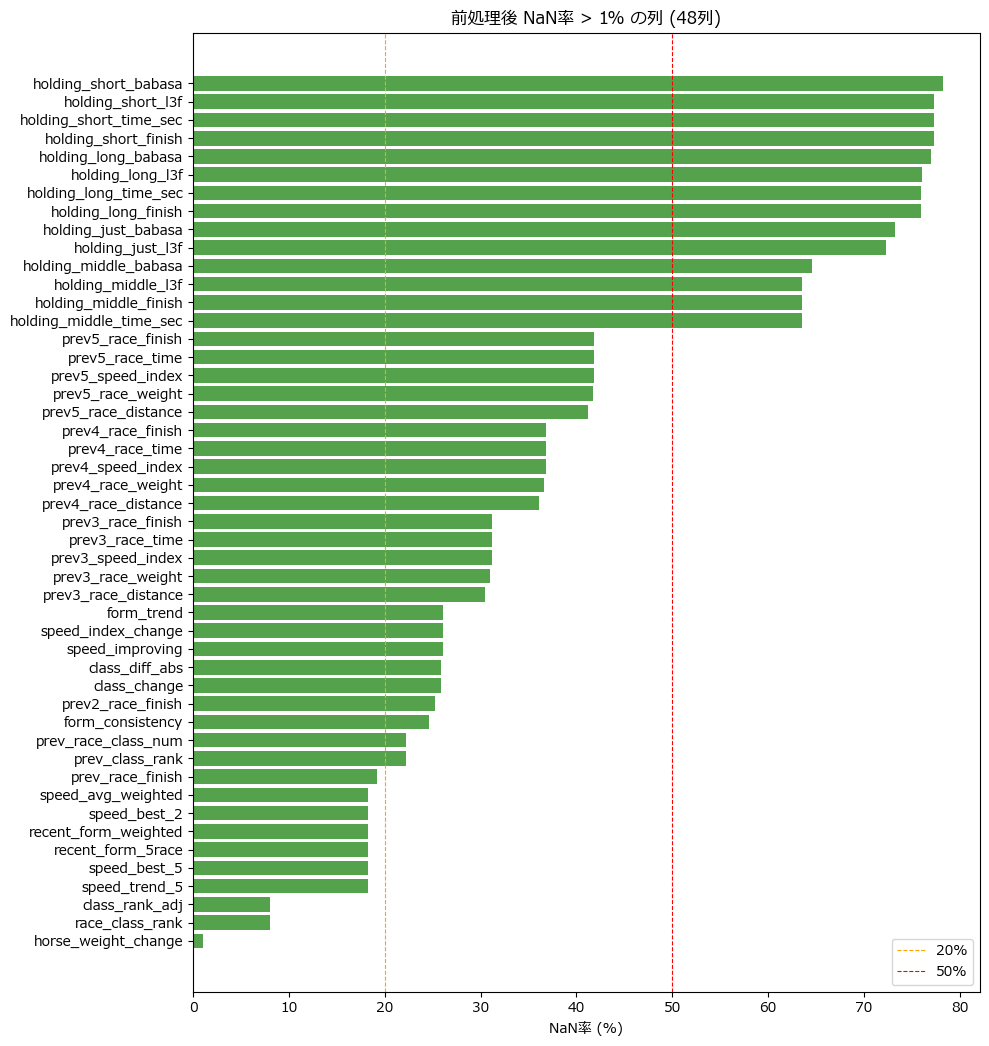


前処理後 NaN完全ゼロ列 : 62 / 111
残存 NaN > 1% 列       : 48


In [13]:
## ── FI-5: 前処理後 NaN率チャート ──────────────────────────────────────────
# feature_inspection.ipynb Cell 10 より移行

_nan_after_fi = _df_fi_pre.isna().mean().sort_values(ascending=False)
_nan_after_top_fi = _nan_after_fi[_nan_after_fi > 0.01].reset_index()
_nan_after_top_fi.columns = ["column", "nan_rate"]
_nan_after_top_fi["nan_%"] = (_nan_after_top_fi["nan_rate"] * 100).round(1)

if len(_nan_after_top_fi) > 0:
    fig_fi5, ax_fi5 = plt.subplots(figsize=(10, max(4, len(_nan_after_top_fi) * 0.22)))
    ax_fi5.barh(_nan_after_top_fi["column"][::-1],
                _nan_after_top_fi["nan_%"][::-1], color="#54A24B")
    ax_fi5.axvline(20, color="orange", linestyle="--", linewidth=0.8, label="20%")
    ax_fi5.axvline(50, color="red",    linestyle="--", linewidth=0.8, label="50%")
    ax_fi5.set_xlabel("NaN率 (%)")
    ax_fi5.set_title(f"前処理後 NaN率 > 1% の列 ({len(_nan_after_top_fi)}列)")
    ax_fi5.legend()
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'nan_rate_after_prep.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("✓ 前処理後は NaN率 > 1% の列はありません")

print(f"\n前処理後 NaN完全ゼロ列 : {(_nan_after_fi == 0).sum()} / {len(_nan_after_fi)}")
print(f"残存 NaN > 1% 列       : {len(_nan_after_top_fi)}")


---
## Section 8 — 欠損値断捨離レポート

`feature_inspection.ipynb` Cells 12-13 より移行。  
各特徴量を NaN率・ゼロ率・ユニーク数で `keep / marginal / drop` に分類し、
`missing_report.csv` として保存する。

判定基準:
- `drop`     : NaN > 60% または ユニーク数 ≤ 1
- `marginal` : NaN 20-60% または ゼロ率 > 80%
- `keep`     : それ以外


In [14]:
## ── FI-6: 欠損値断捨離レポート生成 ───────────────────────────────────────
# feature_inspection.ipynb Cell 12 より移行

def _classify(nan_pct: float, zero_pct: float, unique: int) -> str:
    if nan_pct > 60 or unique <= 1:
        return "drop"
    if nan_pct > 20 or zero_pct > 80:
        return "marginal"
    return "keep"

_report_rows = []
for col in df_fi.columns:
    s = df_fi[col]
    nan_pct = s.isna().mean() * 100
    try:
        zero_pct = (s == 0).mean() * 100 if pd.api.types.is_numeric_dtype(s) else 0.0
    except TypeError:
        zero_pct = 0.0
    try:
        uniq = int(s.nunique(dropna=True))
    except TypeError:
        # list/dict 型など unhashable な列はユニーク数を -1 で記録（drop 対象）
        uniq = -1
    _report_rows.append({
        "column"  : col,
        "dtype"   : str(s.dtype),
        "nan_%"   : round(nan_pct, 2),
        "zero_%"  : round(zero_pct, 2),
        "unique"  : uniq,
        "verdict" : _classify(nan_pct, zero_pct, uniq),
    })

missing_report_df = pd.DataFrame(_report_rows).sort_values("nan_%", ascending=False)

vc = missing_report_df["verdict"].value_counts()
print(f"keep     : {vc.get('keep', 0):>4} 列")
print(f"marginal : {vc.get('marginal', 0):>4} 列")
print(f"drop     : {vc.get('drop', 0):>4} 列")
print(f"合計     : {len(missing_report_df):>4} 列\n")

# pandas 2.x では applymap → map に変更
_style_fn = lambda v: ("color:#E45756;font-weight:bold" if v == "drop"
                        else ("color:#F58518" if v == "marginal" else ""))
_styled = missing_report_df[missing_report_df['verdict'] != 'keep'].style
try:
    _styled = _styled.map(_style_fn, subset=["verdict"])   # pandas >= 2.1
except AttributeError:
    _styled = _styled.applymap(_style_fn, subset=["verdict"])  # pandas < 2.1
_styled = _styled.background_gradient(subset=["nan_%"], cmap="Reds").set_caption("keep 以外の列")
display(_styled)


keep     :  151 列
marginal :   72 列
drop     :   86 列
合計     :  309 列



,column,dtype,nan_%,zero_%,unique,verdict
248,lap_sect_2000m,float64,100.000000,0.000000,0,drop
249,lap_sect_2200m,float64,100.000000,0.000000,0,drop
250,lap_sect_2400m,float64,100.000000,0.000000,0,drop
235,lap_1800m,float64,100.000000,0.000000,1,drop
247,lap_sect_1800m,float64,100.000000,0.000000,1,drop
119,prev5_race_class,category,100.000000,0.000000,6,drop
216,jockey_changed,float64,100.000000,0.000000,0,drop
217,first_jockey,float64,100.000000,0.000000,0,drop
238,lap_2400m,float64,100.000000,0.000000,0,drop
237,lap_2200m,float64,100.000000,0.000000,0,drop


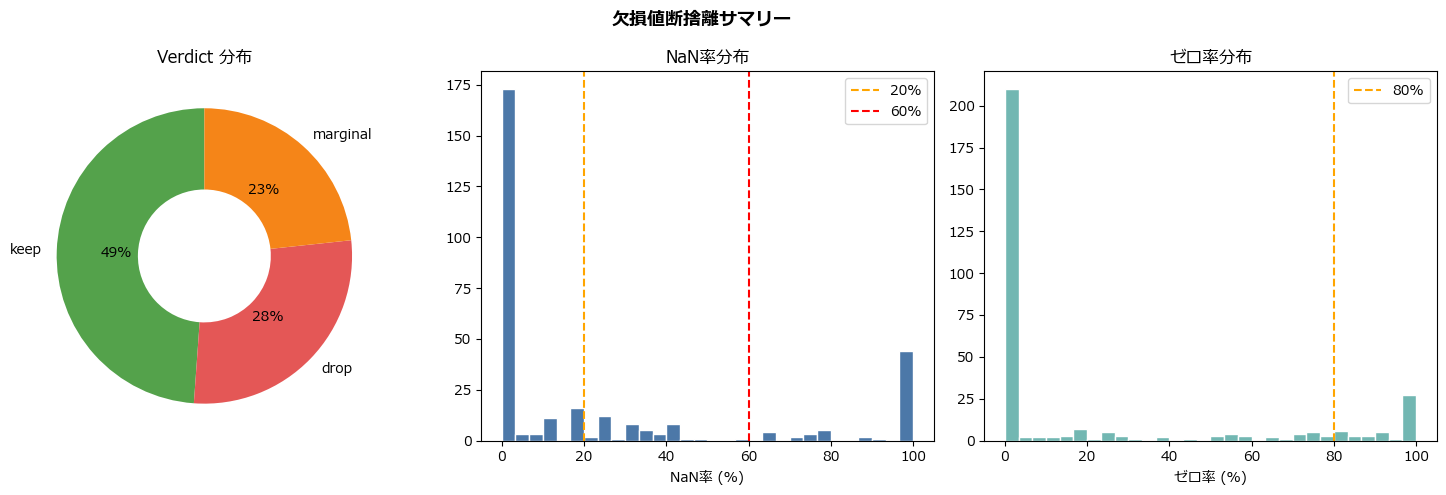

✓ 保存: C:\Users\yuki2\Documents\ws\keiba-ai-pro\notebooks\reports\missing_report.csv


In [15]:
## ── FI-7: 断捨離レポート可視化 + CSV保存 ─────────────────────────────────
# feature_inspection.ipynb Cell 13 より移行

fig_fi7, axes_fi7 = plt.subplots(1, 3, figsize=(15, 5))

# verdict ドーナツチャート
_vc2 = missing_report_df["verdict"].value_counts()
_colors_verdict = {"keep": "#54A24B", "marginal": "#F58518", "drop": "#E45756"}
_cv = [_colors_verdict.get(k, "#AAA") for k in _vc2.index]
axes_fi7[0].pie(_vc2.values, labels=_vc2.index, autopct="%1.0f%%",
                colors=_cv, startangle=90,
                wedgeprops=dict(width=0.55))
axes_fi7[0].set_title("Verdict 分布")

# NaN率分布ヒストグラム
axes_fi7[1].hist(missing_report_df["nan_%"], bins=30, color="#4C78A8", edgecolor="white")
axes_fi7[1].axvline(20, color="orange", linestyle="--", label="20%")
axes_fi7[1].axvline(60, color="red",    linestyle="--", label="60%")
axes_fi7[1].set_xlabel("NaN率 (%)"); axes_fi7[1].set_title("NaN率分布"); axes_fi7[1].legend()

# zero率分布ヒストグラム
axes_fi7[2].hist(missing_report_df["zero_%"], bins=30, color="#72B7B2", edgecolor="white")
axes_fi7[2].axvline(80, color="orange", linestyle="--", label="80%")
axes_fi7[2].set_xlabel("ゼロ率 (%)"); axes_fi7[2].set_title("ゼロ率分布"); axes_fi7[2].legend()

plt.suptitle("欠損値断捨離サマリー", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'missing_report_chart.png', dpi=100, bbox_inches='tight')
plt.show()

# CSV 保存
_out_csv = REPORTS_DIR / "missing_report.csv"
missing_report_df.to_csv(_out_csv, index=False, encoding="utf-8-sig")
print(f"✓ 保存: {_out_csv}")
